# Diffusion Model for MNIST-Pytorch

## Paper: "Denoising Diffusion Probabilistic Models" by Ho et al.

In [1]:
import os
import numpy as np 
import math 
import torch 
import torch.nn as nn 
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset 
from torchvision import datasets, transforms

# configuration and setup 

In [2]:

# set device for computation
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = "cpu"
print(f"Using device: {device}")

# hyperparamters
IMG_SIZE = (1, 28, 28)      # Image dimensions: (Channels, Height, Width)
BATCH_SIZE = 128            # Batch size for training
EPOCHS = 200                # Number of training epochs
T = 200                     # Number of diffusion steps
LR = 2e-4                   # Learning rate for Adam optimizer 
TIME_EMBEDDING_DIM = 128    # Dimension for time step embeddings

BETA_START=1e-4             # starting variance schedule value
BETA_END=0.02               # Ending variance schedule value


Using device: cuda


# Data loading and preprocessing

In [3]:
# load mnist dataset and normalize to [-1, 1] range
# normalization to [-1, 1] helps with training stability in diffusion models

transform = transforms.Compose([
    transforms.ToTensor(), 
    transforms.Normalize([0.5], [0.5])  # scale from [0, 1] to [-1, 1]
])

train_dataset = datasets.MNIST(
    root = './data', 
    train=True,
    download=True,
    transform=transform  
)

test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform)

# combine train and test datasets for larger training set
combined_data = torch.cat([
    train_dataset.data.unsqueeze(1).float() / 127.5-1.0, 
    test_dataset.data.unsqueeze(1).float() / 127.5-1.0
], dim=0)

# create dataset and dataloader
dataset = TensorDataset(combined_data)
dataloader = DataLoader(
    dataset, 
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True 
)


100%|██████████| 9.91M/9.91M [00:00<00:00, 60.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.68MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.77MB/s]


# Visualization utilities

sample batch shape: torch.Size([16, 1, 28, 28])


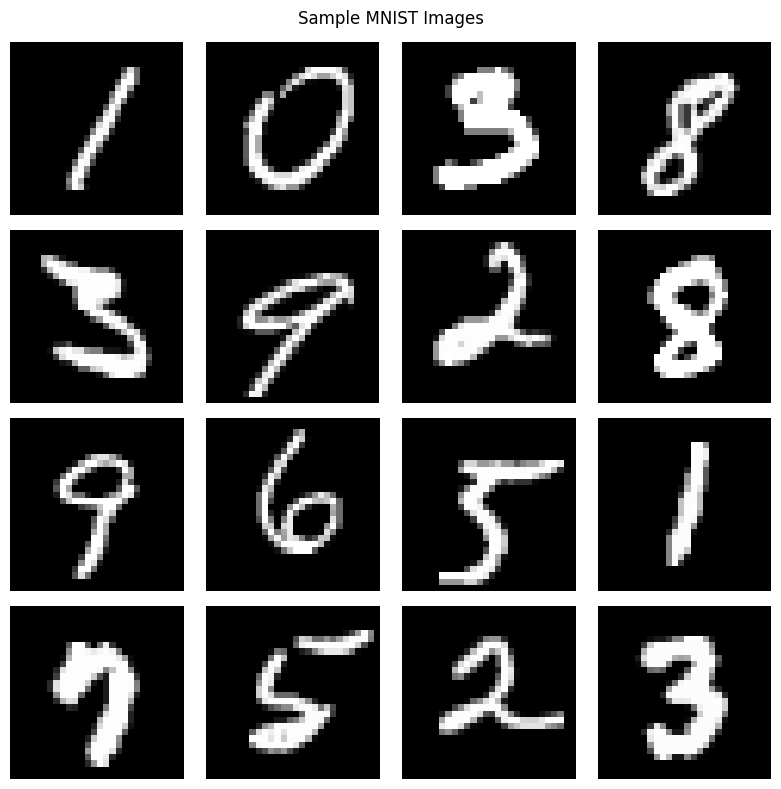

In [4]:
# visualization
import matplotlib.pyplot as plt

def plot_images(images, num_rows=4, num_cols=4, title=None):
    images = (images+1.0)/2.0
    images = images.cpu().numpy()
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(8, 8))
    axes = axes.flatten()

    for idx in range(min(len(images), num_rows*num_cols)):
        axes[idx].imshow(images[idx].squeeze(), cmap='gray', vmin=0, vmax=1)
        axes[idx].axis('off')

    # hide unused subplots
    for idx in range(len(images), num_rows*num_cols):
        axes[idx].axis('off')
    if title:
        plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# display some batch from dataset
sample_batch = next(iter(dataloader))[0][:16]
print("sample batch shape:", sample_batch.shape)
plot_images(sample_batch, title="Sample MNIST Images")

# Diffusion process parameters

In [5]:
# linear variance schedule

# beta controls the amount of noise added at each timestep
betas = torch.linspace(BETA_START, BETA_END, T, dtype=torch.float32).to(device)

# alpha values derived from betas
alphas = 1.0 - betas 

# cumulative product of alphas (alpha_bar_t in the paper)
alpha_cumprod = torch.cumprod(alphas, dim=0)

# precompute commonly used values for efficiency
sqrt_alpha_cumprod = torch.sqrt(alpha_cumprod)
sqrt_one_minus_alpha_cum_prod = torch.sqrt(1.0-alpha_cumprod)

print("Diffusion schedule initialized ...")
print(f"    Beta range: [{BETA_START}, {BETA_END}]")
print(f"    Number of time steps: {T}")

Diffusion schedule initialized ...
    Beta range: [0.0001, 0.02]
    Number of time steps: 200


# time embedding functions

In [6]:
def sinusoidal_time_embedding(timesteps, dim=128):

    # Create sinusoidal positional embeddings for timesteps.
    

    half = dim // 2

    # create frequency values following the transformer positional encoding
    freqs = torch.exp(
        -math.log(10000.0) * torch.arange(0, half, dtype=torch.float32) /float(half)
    ).to(timesteps.device)

    # compute arguments for sin and cos
    args = timesteps.float().unsqueeze(-1) * freqs.unsqueeze(0)

    # concatenate sin and cos embeddings
    emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
    
    if dim%2 == 1:  # if dim is odd, pad with zeros
        emb = F.pad(emb, (0, 1))

    return emb # shape: (batch_size, dim)

# Model components

In [7]:
class TimeEmbedding(nn.Module):
    """ 
    Time embedding module that projects sinusoidal embeddings 
    through two fully connected layers with SiLU activation
    """

    def __init__(self, dim):
        super(TimeEmbedding, self).__init__()
        self.dim = dim 

        self.linear1 = nn.Linear(dim, dim)
        self.activation = nn.SiLU() # SiLU (Swish) activatioin
        self.linear2 = nn.Linear(dim, dim)

    def forward(self, t):
        # forward pass for the time embedding
        emb = sinusoidal_time_embedding(t, self.dim)
        emb = self.activation(self.linear1(emb))
        emb = self.activation(self.linear2(emb))
        return emb 
    
class GroupNorm(nn.Module):
    # Group Normalization wrapper with automatic group count

    def __init__(self, channels):
        super(GroupNorm, self).__init__()
        # use min of 32 or channels to determine number of groups
        self.gn = nn.GroupNorm(num_groups=min(32, channels), num_channels=channels)

    def forward(self, x):
        return self.gn(x)
    
class ResidualBlock(nn.Module):
    # Residual block with time embedding injection
    def __init__(self, in_channels, out_channels, time_emb_dim):
        super(ResidualBlock, self).__init__()

        self.in_channels = in_channels
        self.out_channels = out_channels

        # first conv path
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.gn1 = GroupNorm(out_channels)
        self.activation = nn.SiLU()

        # time embedding projection
        self.time_proj = nn.Linear(time_emb_dim, out_channels)

        # second conv path 
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.gn2 = GroupNorm(out_channels)

        # Residual connection (1x1 conv if in_channels != out_channels)

        if in_channels != out_channels: 
            self.residual_conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        else:
            self.residual_conv = nn.Identity()

    def forward(self, x, t_emb):
        # forward pass for residal block

        # first conv block
        h = self.conv1(x)
        h = self.gn1(h)
        h = self.activation(h)

        # project and inject time embedding
        t_proj = self.activation(self.time_proj(t_emb))
        t_proj = t_proj.view(-1, self.out_channels, 1, 1)
        h = h + t_proj 

        # second conv block
        h = self.conv2(h)
        h = self.gn2(h)

        # apply residual connection
        x_residual  = self.residual_conv(x)
        out = self.activation(x_residual+h)
        
        return out 
    
class EpsilonModel(nn.Module):
    # U-Net based noise prediction model for diffusion

    def __init__(self, img_channels=1, time_emb_dim=128):
        super(EpsilonModel, self).__init__()

        # time embedding module
        self.time_emb = TimeEmbedding(time_emb_dim)

        # encoder path (downsampling)
        self.enc1 = ResidualBlock(img_channels, 64, time_emb_dim)
        self.down1 = nn.Conv2d(64, 64, kernel_size=3, stride=2, padding=1)

        self.enc2 = ResidualBlock(64, 128, time_emb_dim)
        self.down2 = nn.Conv2d(128, 128, kernel_size=3, stride=2, padding=1)

        self.enc3 = ResidualBlock(128, 256, time_emb_dim)
        
        # bottleneck
        self.bottleneck = ResidualBlock(256, 512, time_emb_dim)

        # decoder path
        self.up1 = nn.ConvTranspose2d(512, 256, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.dec1 = ResidualBlock(256+128, 256, time_emb_dim)
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.dec2 = ResidualBlock(128+64, 128, time_emb_dim)

        # output layer
        self.out_conv = nn.Conv2d(128, img_channels, kernel_size=3, padding=1)

    def forward(self, x, t):
        # forward pass for noise prediction

        # generate time embeddings
        t_emb = self.time_emb(t)

        # encoder path with skip connections
        x1 = self.enc1(x, t_emb)        # 28x28x64
        x_down1 = self.down1(x1)        # 14x14x64

        x2 = self.enc2(x_down1, t_emb)  # 14x14x128
        x_down2 = self.down2(x2)        # 7x7x128

        x3 = self.enc3(x_down2, t_emb)  # 7x7x256

        # bottleneck
        x_bottle = self.bottleneck(x3, t_emb) # 14x14x256
        x_up1 = self.up1(x_bottle)
        x_up1 = torch.cat([x_up1, x2], dim=1) # concatenate with x2
        x_dec1 = self.dec1(x_up1, t_emb)    # 14x14x256

        x_up2 = self.up2(x_dec1)    # 28x28x128
        x_up2 = torch.cat([x_up2, x1], dim=1) # concatenate with x1
        x_dec2 = self.dec2(x_up2, t_emb) # 28x28x128

        # output prediction
        out = self.out_conv(x_dec2)

        return out 


# model initialization

In [8]:
# initialize the noise prediction model 
epsilon_model = EpsilonModel(img_channels=1, time_emb_dim=TIME_EMBEDDING_DIM).to(device)

# count and display model parameters
total_params = sum(p.numel() for p in epsilon_model.parameters())
trainable_params = sum(p.numel() for p in epsilon_model.parameters() if p.requires_grad)

print("\n\n\nModel Architecture summary: ")
print(f"     total parameters: {total_params},")
print(f"     trainable parameters: {trainable_params}, ")
print("\n\n")




Model Architecture summary: 
     total parameters: 8696897,
     trainable parameters: 8696897, 





# initialize optimizer

In [9]:
optimizer = torch.optim.Adam(
    epsilon_model.parameters(), 
    lr = LR, 
    betas = (0.9, 0.999), 
    eps=1e-8
)

# training functions

In [10]:
def train_step(x0):
    # perform a single training step 

    batch_size = x0.shape[0]
    x0 = x0.to(device)

    # sample random timesteps for each image in the batch
    t = torch.randint(0, T, (batch_size,), device=device, dtype=torch.long)

    # gather alpha values for the sampled timesteps
    alpha_bar = sqrt_alpha_cumprod[t].view(-1, 1, 1, 1)
    one_minus_alpha_bar = sqrt_one_minus_alpha_cum_prod[t].view(-1, 1, 1, 1)

    # sample random gaussian noise
    eps = torch.randn_like(x0)

    # create noisy image using the forward diffusion process
    # x_t = alpha_bar * x0 + one_minus_alpha_bar * eps
    x_t = alpha_bar * x0 + one_minus_alpha_bar * eps

    # predict the noise
    eps_pred = epsilon_model(x_t, t)

    # compute mse loss
    loss = F.mse_loss(eps_pred, eps)

    return loss 

# sampling functions

In [11]:
from tqdm import tqdm

@torch.no_grad() 
def sample(n_samples=16, show_progress=True):
    # generate samples using the reverse diffusion process

    epsilon_model.eval() 

    # start from pure gaussian noise
    x_t = torch.randn(n_samples, *IMG_SIZE).to(device)

    # reverse diffusion process
    timesteps = reversed(range(T))
    if show_progress:
        timesteps = tqdm(timesteps, desc='Sampling', total=T)

    for t_i in timesteps:

        # create batch of current timestep
        t_batch = torch.full((n_samples,), t_i, device=device, dtype=torch.long)

        # predice noise at current timestep
        eps_pred = epsilon_model(x_t, t_batch)

        # get diffusion parameters for current timestep
        beta_i = betas[t_i].item()
        alpha_i = alphas[t_i].item()
        alpha_bar_i = alpha_cumprod[t_i].item()

        # compute coefficient for noise removal
        coef = beta_i / math.sqrt(1.0 - alpha_bar_i)

        # add noise for all timesteps except the last
        if t_i > 0:
            z = torch.randn_like(x_t)
        else:
            z=torch.zeros_like(x_t)

        # variance for current timestep
        sigma_t = math.sqrt(beta_i)

        # perform reverse diffusion step
        # x_{t-1} = (1/sqrt(alpha_t)) * (x_t - coef * eps_pred) + sigma_t * z
        x_t = (1.0 / math.sqrt(alpha_i)) * (x_t - coef * eps_pred) + sigma_t * z 

    epsilon_model.train()
    return x_t 

In [12]:
def save_generated_images(epoch, sample_fn, out_dir='./generated_images/', num_samples=16):
    
    # Generate and save a grid of images to disk.

    os.makedirs(out_dir, exist_ok=True)
    
    print(f'\n[INFO] Generating samples for epoch {epoch + 1}...')
    
    # Generate samples
    images = sample_fn(num_samples, show_progress=False).cpu()
    
    # Scale from [-1, 1] to [0, 255]
    images = (images + 1.0) * 127.5
    images = torch.clamp(images, 0, 255).numpy().astype(np.uint8)
    
    # Create and save plot
    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    axes = axes.flatten()
    
    for idx in range(min(num_samples, 16)):
        axes[idx].imshow(images[idx].squeeze(), cmap='gray')
        axes[idx].axis('off')
    
    for idx in range(num_samples, 16):
        axes[idx].axis('off')
    
    plt.suptitle(f'Generated Images - Epoch {epoch + 1}', fontsize=16)
    
    file_path = os.path.join(out_dir, f'image_at_epoch_{epoch:04d}.png')
    plt.savefig(file_path, bbox_inches='tight', dpi=150)
    plt.close()
    
    print(f'[INFO] Saved generated images to {file_path}')

# Main Training Loop

In [13]:
def train_model(dataloader, epochs, checkpoint_dir='./checkpoints'):
    # main training loop for the diffusion model.

    os.makedirs(checkpoint_dir, exist_ok=True)
    
    epsilon_model.train()

    print(f'\n\nStarting Training')
    print(f'    Epochs: {epochs}')
    print(f'    Batch size: {BATCH_SIZE}')
    print(f'    Learning rate: {LR}')
    print(f'    Device: {device}')
    print('\n\n')
    
    for epoch in range(epochs):
        print(f'\nEpoch [{epoch + 1}/{epochs}]')
        print('-' * 70)
        
        epoch_loss = 0.0
        num_batches = 0
        
        # Training loop with progress bar
        progress_bar = tqdm(dataloader, desc='Training')
        
        for batch_idx, (batch,) in enumerate(progress_bar):
            # Zero gradients
            optimizer.zero_grad()
            
            # Forward pass and compute loss
            loss = train_step(batch)
            
            # Backward pass
            loss.backward()
            
            # Gradient clipping for training stability
            torch.nn.utils.clip_grad_norm_(epsilon_model.parameters(), 1.0)
            
            # Update model parameters
            optimizer.step()
            
            # Accumulate loss
            epoch_loss += loss.item()
            num_batches += 1
            
            # Update progress bar
            progress_bar.set_postfix({
                'loss': f'{loss.item():.6f}',
                'avg_loss': f'{epoch_loss / num_batches:.6f}'
            })
        
        # Calculate average epoch loss
        avg_loss = epoch_loss / num_batches
        
        print(f'\nEpoch {epoch + 1} Summary:')
        print(f'  Average Loss: {avg_loss:.6f}')
        
        # Generate and save sample images
        save_generated_images(epoch, sample, out_dir='./generated_images')
        
        # Save checkpoint every 10 epochs
        if (epoch + 1) % 10 == 0:
            checkpoint_path = os.path.join(
                checkpoint_dir, 
                f'checkpoint_epoch_{epoch + 1}.pt'
            )
            
            checkpoint = {
                'epoch': epoch + 1,
                'model_state_dict': epsilon_model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': avg_loss,
                'hyperparameters': {
                    'T': T,
                    'beta_start': BETA_START,
                    'beta_end': BETA_END,
                    'lr': LR,
                    'batch_size': BATCH_SIZE,
                    'time_emb_dim': TIME_EMBEDDING_DIM
                }
            }
            
            torch.save(checkpoint, checkpoint_path)
            print(f'  Checkpoint saved: {checkpoint_path}')
        
        print('-' * 70)

    print('\n\nTraining Complete!')


# Execute Training



Starting Training
    Epochs: 200
    Batch size: 128
    Learning rate: 0.0002
    Device: cuda




Epoch [1/200]
----------------------------------------------------------------------


Training: 100%|██████████| 547/547 [01:43<00:00,  5.28it/s, loss=0.063379, avg_loss=0.087456]



Epoch 1 Summary:
  Average Loss: 0.087456

[INFO] Generating samples for epoch 1...
[INFO] Saved generated images to ./generated_images/image_at_epoch_0000.png
----------------------------------------------------------------------

Epoch [2/200]
----------------------------------------------------------------------


Training: 100%|██████████| 547/547 [02:02<00:00,  4.46it/s, loss=0.046357, avg_loss=0.054931]



Epoch 2 Summary:
  Average Loss: 0.054931

[INFO] Generating samples for epoch 2...
[INFO] Saved generated images to ./generated_images/image_at_epoch_0001.png
----------------------------------------------------------------------

Epoch [3/200]
----------------------------------------------------------------------


...

Training: 100%|██████████| 547/547 [02:01<00:00,  4.49it/s, loss=0.033929, avg_loss=0.036009]



Epoch 199 Summary:
  Average Loss: 0.036009

[INFO] Generating samples for epoch 199...
[INFO] Saved generated images to ./generated_images/image_at_epoch_0198.png
----------------------------------------------------------------------

Epoch [200/200]
----------------------------------------------------------------------


Training: 100%|██████████| 547/547 [02:02<00:00,  4.48it/s, loss=0.036233, avg_loss=0.035882]



Epoch 200 Summary:
  Average Loss: 0.035882

[INFO] Generating samples for epoch 200...
[INFO] Saved generated images to ./generated_images/image_at_epoch_0199.png
  Checkpoint saved: ./checkpoints/checkpoint_epoch_200.pt
----------------------------------------------------------------------


Training Complete!

[INFO] Final model saved to: diffusion_model_final.pt

[INFO] Generating final samples...


Sampling: 100%|██████████| 200/200 [00:02<00:00, 92.67it/s]


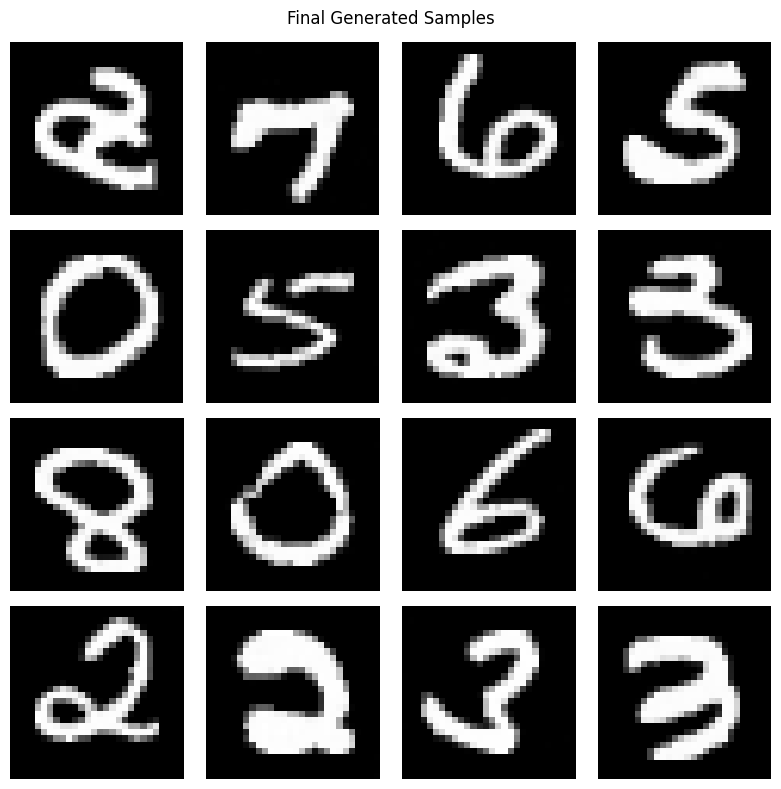


[INFO] All tasks completed successfully!


In [14]:
if __name__ == '__main__':
    # Start training
    train_model(dataloader, EPOCHS)
    
    # Save final model
    final_model_path = 'diffusion_model_final.pt'
    
    torch.save({
        'model_state_dict': epsilon_model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'hyperparameters': {
            'T': T,
            'beta_start': BETA_START,
            'beta_end': BETA_END,
            'lr': LR,
            'batch_size': BATCH_SIZE,
            'time_emb_dim': TIME_EMBEDDING_DIM
        }
    }, final_model_path)
    
    print(f'\n[INFO] Final model saved to: {final_model_path}')
    
    # Generate final sample images
    print('\n[INFO] Generating final samples...')
    final_samples = sample(n_samples=16, show_progress=True)
    plot_images(final_samples, num_rows=4, num_cols=4, 
                title='Final Generated Samples')
    
    print('\n[INFO] All tasks completed successfully!')

# Model Loading Example

To load a saved model checkpoint:
```python
checkpoint = torch.load('diffusion_model_final.pt', map_location=device)
epsilon_model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

# Generate new samples
new_samples = sample(n_samples=16)
plot_images(new_samples)
```